In [3]:
import pandas as pd

In [4]:
# Load the training data
train_trans = pd.read_csv('train_transaction.csv')
train_id = pd.read_csv('train_identity.csv')

In [5]:
# Merge them: Keep all transactions, add identity where available
train = pd.merge(train_trans, train_id, on='TransactionID', how='left')

In [6]:
print(f"Master Dataset Shape: {train.shape}")
print(f"Fraud Rate: {round(train['isFraud'].mean() * 100, 2)}%")

Master Dataset Shape: (35339, 434)
Fraud Rate: 2.87%


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_8042/899611292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=train, palette='viridis')


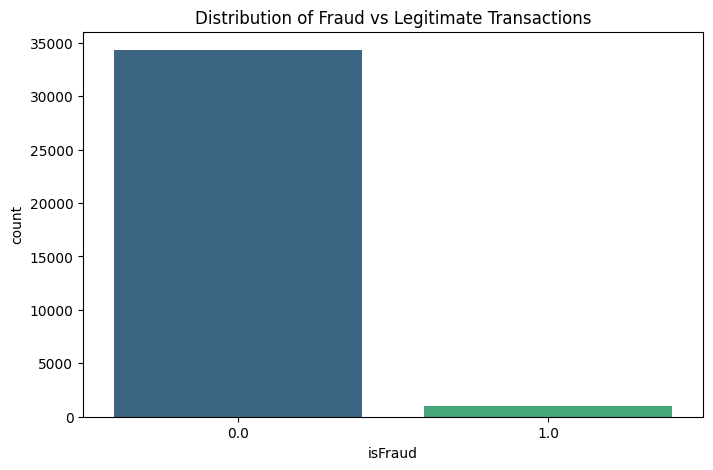

In [8]:
# Visualizing the class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='isFraud', data=train, palette='viridis')
plt.title('Distribution of Fraud vs Legitimate Transactions')
plt.show()

In [9]:
print(f"Total Transactions: {len(train)}")
print(f"Fraudulent Transactions: {train['isFraud'].sum()}")

Total Transactions: 35339
Fraudulent Transactions: 1015.0


In [10]:
# Calculate fraud rate by Device Type
device_risk = train.groupby('DeviceType')['isFraud'].mean().sort_values(ascending=False)

/tmp/ipykernel_8042/3029227068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_risk.index, y=device_risk.values, palette='Reds_r')


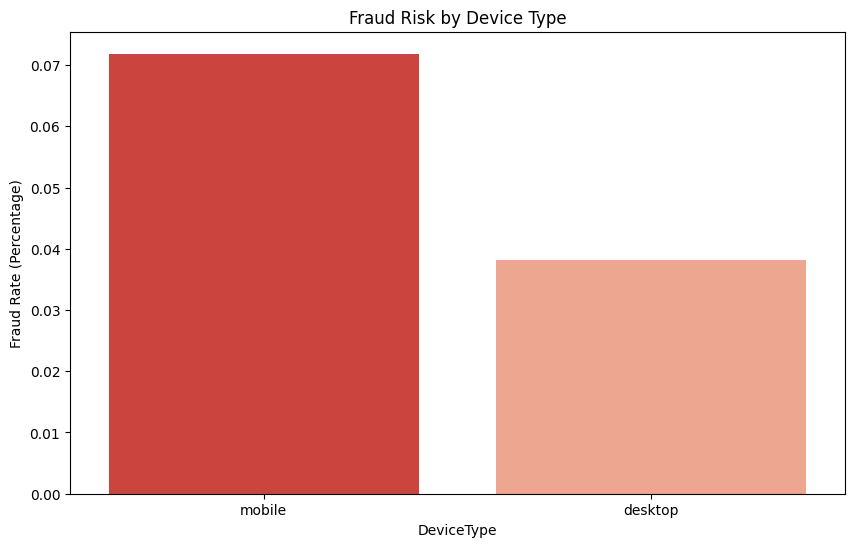

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x=device_risk.index, y=device_risk.values, palette='Reds_r')
plt.ylabel('Fraud Rate (Percentage)')
plt.title('Fraud Risk by Device Type')
plt.show()

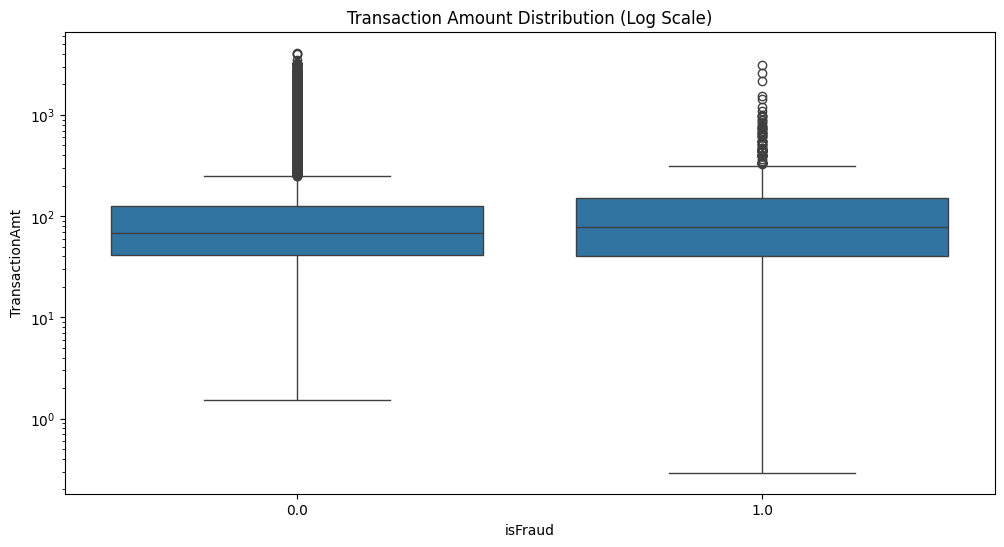

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='isFraud', y='TransactionAmt', data=train)
plt.yscale('log') # Log scale is vital for financial data
plt.title('Transaction Amount Distribution (Log Scale)')
plt.show()

In [13]:
import numpy as np

In [14]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')

    return df

# Apply it to your merged 'train' dataframe
train = reduce_mem_usage(train)

Memory usage of dataframe is 117.01 MB


/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_8042/3754420225.py:21: RuntimeW

Memory usage after optimization is: 30.03 MB
Decreased by 74.3%


In [15]:
# Drop columns with more than 80% missing values
null_cols = [col for col in train.columns if train[col].isnull().sum() / train.shape[0] > 0.80]
train.drop(columns=null_cols, inplace=True)

print(f"Dropped {len(null_cols)} columns with high null counts.")

Dropped 27 columns with high null counts.


In [16]:
# Since TransactionDT is a time-delta, we split by value
# We'll use the first 80% of time for training, and the last 20% for validation
train = train.sort_values('TransactionDT')
split_idx = int(len(train) * 0.8)

In [17]:
X = train.drop(['isFraud', 'TransactionID'], axis=1)
y = train['isFraud']

In [18]:
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

In [19]:
import lightgbm as lgb

In [20]:
# Define the categorical features (LightGBM handles these natively!)
cat_features = [col for col in X_train.columns if X_train[col].dtype.name == 'category']

In [21]:
# Create the LightGBM Dataset
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features, reference=dtrain)

In [22]:
# Parameters for Fraud
params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',          # AUC is better than Accuracy for imbalanced data
    'is_unbalance': True,     # Automatically balances the weight of Fraud vs Legit
    'learning_rate': 0.02,    # Slow learning rate for better precision
    'num_leaves': 64,         # Higher leaves can capture complex fraud patterns
    'feature_fraction': 0.8,  # Randomly select features to prevent overfitting
    'bagging_fraction': 0.8,  # Randomly select data rows
    'bagging_freq': 5,
    'random_state': 42
}

# Train the model
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # Stops if the model stops improving
)

[LightGBM] [Info] Number of positive: 823, number of negative: 27448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.105405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22130
[LightGBM] [Info] Number of data points in the train set: 28271, number of used features: 403
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.029111 -> initscore=-3.507092
[LightGBM] [Info] Start training from score -3.507092
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[499]	training's auc: 1	valid_1's auc: 0.897326


In [23]:
from sklearn.metrics import precision_recall_curve

In [24]:
# Get probability predictions
y_probs = model.predict(X_val)

In [28]:
# Calculate precision and recall for different thresholds
# First, identify non-NaN positions in y_val
not_na_mask = y_val.notna()

# Clean y_val and y_probs using the mask
y_val_cleaned = y_val[not_na_mask]
y_probs_cleaned = y_probs[not_na_mask.values]

precision, recall, thresholds = precision_recall_curve(y_val_cleaned, y_probs_cleaned)

In [29]:
# Find the threshold that gives us ~96% Recall (your resume bullet goal)
target_recall = 0.96
idx = np.where(recall >= target_recall)[0][-1]
custom_threshold = thresholds[idx]

In [30]:
print(f"To reach {target_recall*100}% Recall, we should use a threshold of: {custom_threshold:.4f}")

To reach 96.0% Recall, we should use a threshold of: 0.0011


In [31]:
from sklearn.metrics import confusion_matrix

In [34]:
# Apply custom threshold
y_pred_custom = (y_probs_cleaned >= custom_threshold).astype(int)

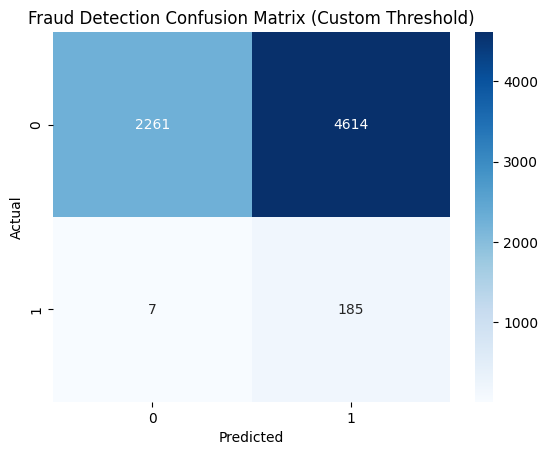

In [35]:
# Create Confusion Matrix
cm = confusion_matrix(y_val_cleaned, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fraud Detection Confusion Matrix (Custom Threshold)')
plt.show()

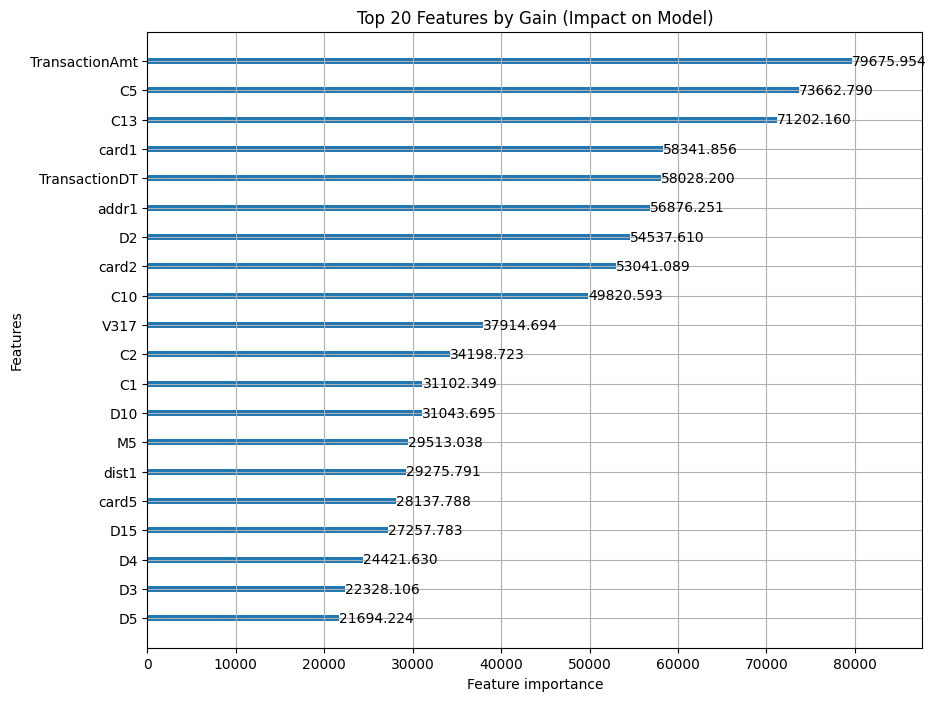

In [36]:
# Plotting the top 20 features
lgb.plot_importance(model, max_num_features=20, figsize=(10, 8), importance_type='gain')
plt.title('Top 20 Features by Gain (Impact on Model)')
plt.show()

In [37]:
# Calculate business impact
false_negatives = cm[1][0]
false_positives = cm[0][1]

avg_fraud_val = X_val.loc[y_val == 1, 'TransactionAmt'].mean()

print(f"Potential Fraud Loss Saved: ${ (cm[1][1] * avg_fraud_val):,.2f}")
print(f"Customer Friction (False Alarms): {false_positives} transactions")

Potential Fraud Loss Saved: $23,911.25
Customer Friction (False Alarms): 4614 transactions


In [39]:
import joblib

# Save the model
joblib.dump(model, 'lgb_fraud_model.pkl')

# Save the list of features used (crucial for deployment)
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

print("Model and Feature list saved for deployment!")

Model and Feature list saved for deployment!
